# 02f: Complete EDA Case Study
## NYC Public Schools SAT Performance Analysis

![NYC School Bus](../data_files/schoolbus.jpg)

*Photo by Jannis Lucas on Unsplash*

---

## Business Context

Every year, American high school students take SATs - standardized tests measuring literacy, numeracy, and writing skills. Each section (reading, math, writing) has a **maximum score of 800 points**, for a total possible score of **2400**.

### Stakeholders
- **Parents**: Choosing schools for their children
- **Policy makers**: Allocating resources and identifying struggling schools
- **School administrators**: Benchmarking against other schools
- **Researchers**: Understanding educational outcomes

### Key Questions
1. Which NYC schools have the best SAT performance?
2. How do boroughs compare in terms of educational outcomes?
3. What percentage of students are tested, and does this affect scores?
4. Are there patterns in school performance we should investigate?

---

## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

print("Libraries imported successfully!")

Libraries imported successfully!


---

## Step 1: LOAD the Data

In [3]:
# Load the dataset
schools = pd.read_csv('./schools.csv')
print(f"Dataset loaded: {schools.shape[0]} schools, {schools.shape[1]} columns")
print(f"\nColumns: {list(schools.columns)}")

Dataset loaded: 375 schools, 7 columns

Columns: ['school_name', 'borough', 'building_code', 'average_math', 'average_reading', 'average_writing', 'percent_tested']


---

## Step 2: INSPECT the Data

In [11]:
# First look at the data
schools.head(10)

,school_name,borough,building_code,average_math,average_reading,average_writing,percent_tested
0,"New Explorations into Science, Technology and ...",Manhattan,M022,657,601,601,NaN
1,Essex Street Academy,Manhattan,M445,395,411,387,78.9
2,Lower Manhattan Arts Academy,Manhattan,M445,418,428,415,65.1
3,High School for Dual Language and Asian Studies,Manhattan,M445,613,453,463,95.9
4,Henry Street School for International Studies,Manhattan,M056,410,406,381,59.7
5,Bard High School Early College,Manhattan,M097,634,641,639,70.8
6,Urban Assembly Academy of Government and Law,Manhattan,M445,389,395,381,80.8
7,Marta Valle High School,Manhattan,M025,438,413,394,35.6
8,University Neighborhood High School,Manhattan,M446,437,355,352,69.9
9,New Design High School,Manhattan,M445,381,396,372,73.7


In [7]:
# Data types and missing values
schools.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   school_name      375 non-null    object 
 1   borough          375 non-null    object 
 2   building_code    375 non-null    object 
 3   average_math     375 non-null    int64  
 4   average_reading  375 non-null    int64  
 5   average_writing  375 non-null    int64  
 6   percent_tested   355 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 20.6+ KB


In [8]:
# Statistical summary
schools.describe()

,average_math,average_reading,average_writing,percent_tested
count,375.000000,375.000000,375.000000,355.000000
mean,432.944000,424.504000,418.458667,64.976338
std,71.952373,61.881069,64.548599,18.747634
min,317.000000,302.000000,284.000000,18.500000
25%,386.000000,386.000000,382.000000,50.950000
50%,415.000000,413.000000,403.000000,64.800000
75%,458.500000,445.000000,437.500000,79.600000
max,754.000000,697.000000,693.000000,100.000000


## Step 3: CLEAN the Data

In [21]:
df = schools.copy()
missing_tested = df['percent_tested'].isnull().mean() * 100
missing_tested

np.float64(5.333333333333334)

Skewness Score: -0.0881


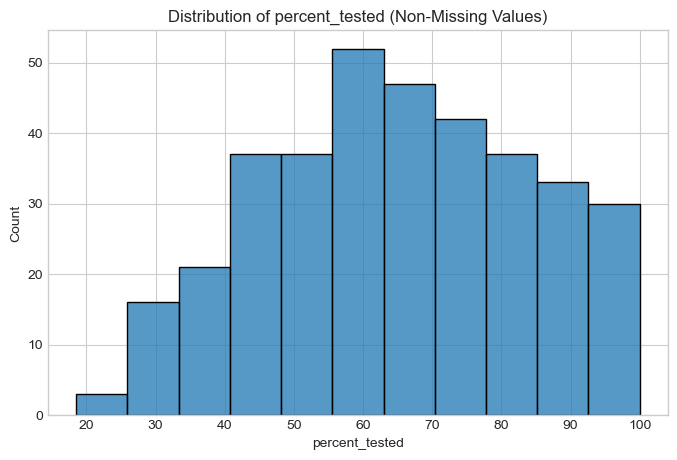

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(x=df['percent_tested'].dropna())
plt.xlabel('percent_tested')
plt.ylabel('Count')
plt.title('Distribution of percent_tested (Non-Missing Values)')
skewness_val = df['percent_tested'].skew()
print(f"Skewness Score: {skewness_val:.4f}")
plt.show()

Data for percent_tested is relatively balanced with skew of less than 1%, which means we could impute using mean

In [22]:
mean = df['percent_tested'].mean()
print(f"Mean: {mean}")
df['percent_tested'] = df['percent_tested'].fillna(mean)
df.head()

Mean: 64.97633802816901


,school_name,borough,building_code,average_math,average_reading,average_writing,percent_tested
0,"New Explorations into Science, Technology and ...",Manhattan,M022,657,601,601,64.976338
1,Essex Street Academy,Manhattan,M445,395,411,387,78.900000
2,Lower Manhattan Arts Academy,Manhattan,M445,418,428,415,65.100000
3,High School for Dual Language and Asian Studies,Manhattan,M445,613,453,463,95.900000
4,Henry Street School for International Studies,Manhattan,M056,410,406,381,59.700000


---

## Step 4: EXPLORE the Data

### 4.1 Univariate Analysis: Distribution of SAT Scores

In [23]:
df['average_sat'] = df['average_math'] + df['average_reading'] + df['average_writing']

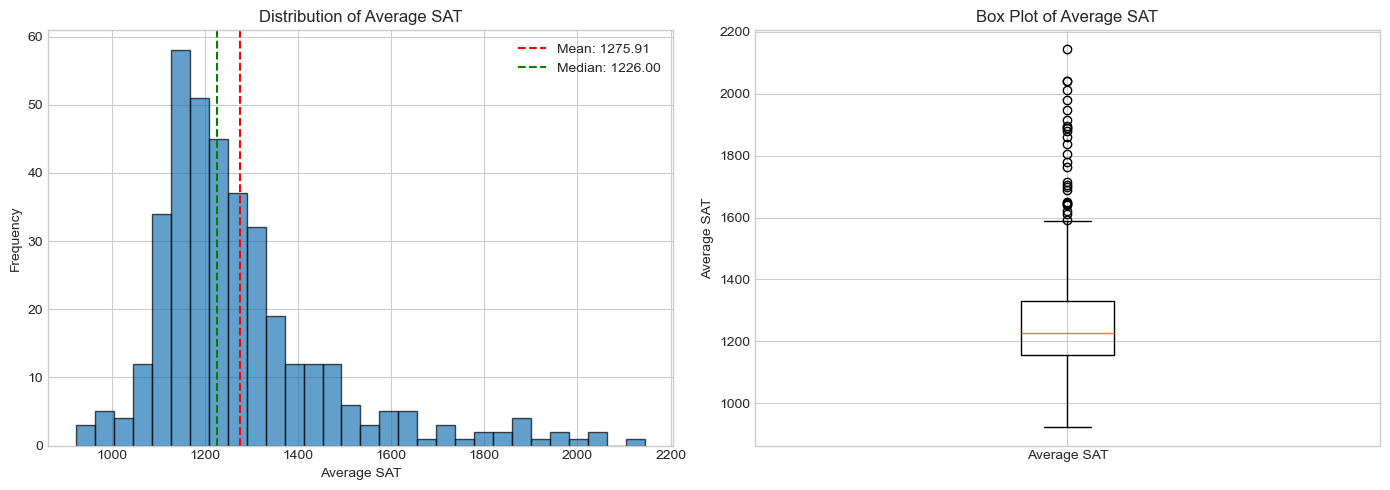

Mean: 1275.91 points
Median: 1226.00 points
Std Dev: 194.91 points


In [25]:
# Histogram and Box Plot for Average SAT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['average_sat'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Average SAT')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Average SAT')
axes[0].axvline(df['average_sat'].mean(), color='red', linestyle='--',
label=f'Mean: {df["average_sat"].mean():.2f}')
axes[0].axvline(df['average_sat'].median(), color='green', linestyle='--',
label=f'Median: {df["average_sat"].median():.2f}')
axes[0].legend()

# Box Plot
axes[1].boxplot(df['average_sat'].dropna(), vert=True)
axes[1].set_ylabel('Average SAT')
axes[1].set_title('Box Plot of Average SAT')
axes[1].set_xticklabels(['Average SAT'])

plt.tight_layout()
plt.show()

# Statistics
print(f"Mean: {df['average_sat'].mean():.2f} points")
print(f"Median: {df['average_sat'].median():.2f} points")
print(f"Std Dev: {df['average_sat'].std():.2f} points")

### 4.2 Schools by Borough

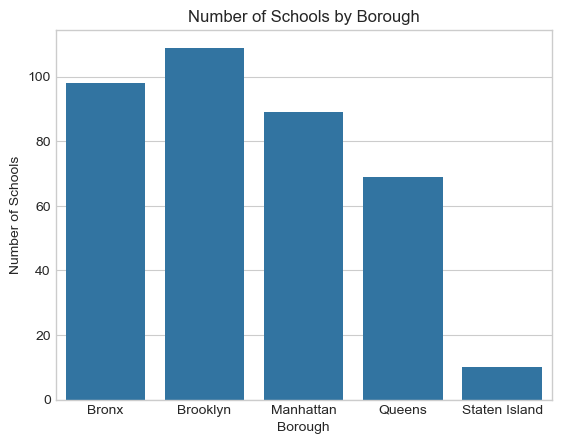

In [28]:
schools_by_borough = df.groupby('borough')['school_name'].count()
sns.barplot(x=schools_by_borough.index, y=schools_by_borough.values)
plt.xlabel('Borough')
plt.ylabel('Number of Schools')
plt.title('Number of Schools by Borough')
plt.show()

### 4.3 Bivariate Analysis: SAT Scores by Borough

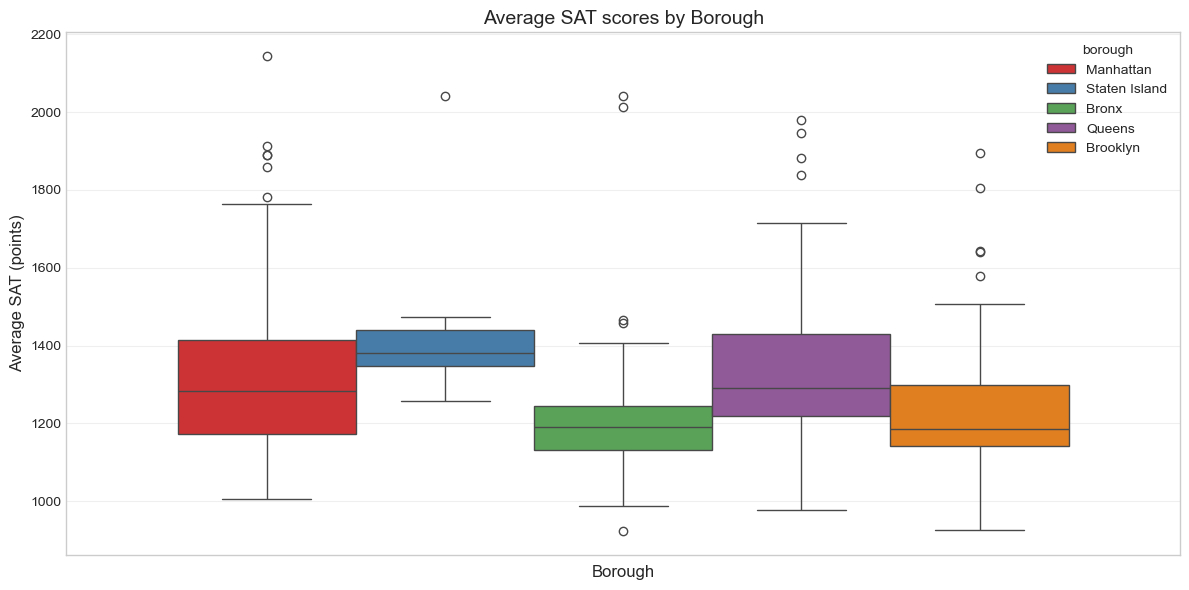


Average SAT scores by Borough:
                      mean  median  count
borough                                  
Bronx          1202.724490  1190.0     98
Brooklyn       1230.256881  1186.0    109
Manhattan      1340.134831  1284.0     89
Queens         1345.478261  1290.0     69
Staten Island  1439.000000  1382.0     10


In [34]:
# Box plot: Average SAT by Number of Kids
plt.figure(figsize=(12, 6))

# Create box plot
sns.boxplot(df, hue='borough', y='average_sat', palette='Set1', legend=True)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Average SAT (points)', fontsize=12)
plt.title('Average SAT scores by Borough', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics by borough
print("\nAverage SAT scores by Borough:")
print(df.groupby('borough')['average_sat'].agg(['mean', 'median', 'count']))

### 4.4 Correlation Analysis

In [36]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

Numerical columns:
['average_math', 'average_reading', 'average_writing', 'percent_tested', 'average_sat']


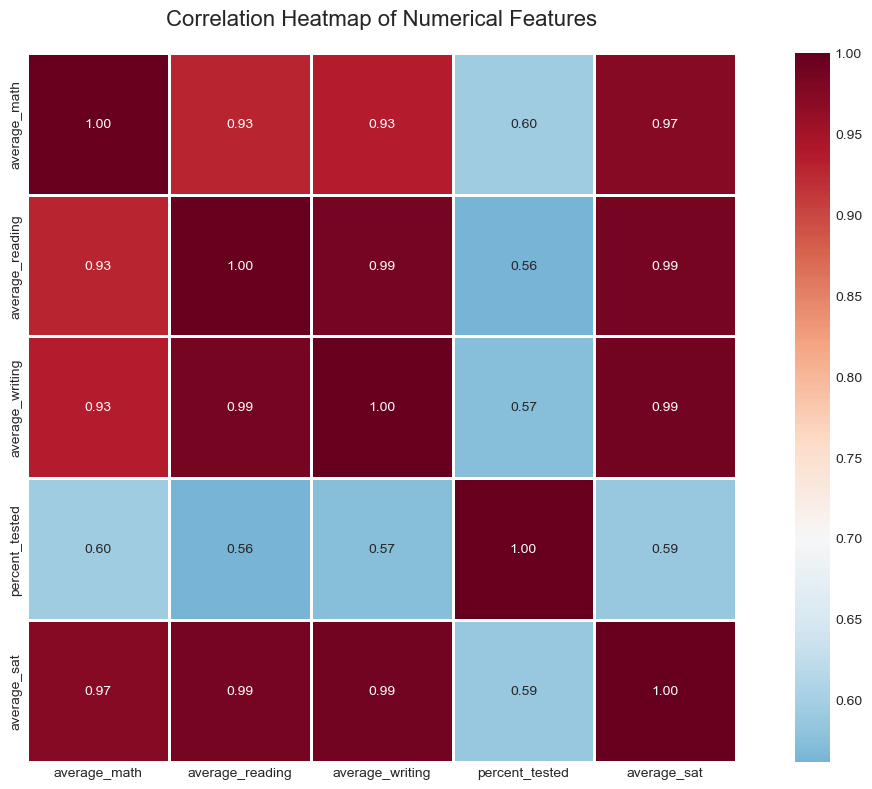

In [58]:
correlation_matrix = df[numerical_cols].corr()

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0.7,
            square=True, linewidths=1, fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

### percentage of students tested showed a slight positive correlation with the scores: suggesting that schools with higher testing rate might produce higher scores, however the correlation is too small to conclude anything

### 4.5 Top Performing Schools

In [77]:
top_schools = df.sort_values('average_sat', ascending=False).head(25)
top_schools[['school_name', 'borough', 'average_sat', 'percent_tested']]

,school_name,borough,average_sat,percent_tested
88,Stuyvesant High School,Manhattan,2144,97.400000
170,Bronx High School of Science,Bronx,2041,97.000000
93,Staten Island Technical High School,Staten Island,2041,99.700000
174,High School of American Studies at Lehman College,Bronx,2013,91.800000
333,Townsend Harris High School,Queens,1981,97.100000
365,Queens High School for the Sciences at York Co...,Queens,1947,97.900000
5,Bard High School Early College,Manhattan,1914,70.800000
280,Brooklyn Technical High School,Brooklyn,1896,95.500000
45,Eleanor Roosevelt High School,Manhattan,1889,86.000000
68,"High School for Mathematics, Science, and Engi...",Manhattan,1889,92.600000


In [78]:
top_schools['borough'].value_counts()

borough
Manhattan        12
Queens            6
Brooklyn          4
Bronx             2
Staten Island     1
Name: count, dtype: int64

### 4.6 Struggling Schools

In [79]:
bottom_schools = df.sort_values('average_sat', ascending=True).head(25)
bottom_schools[['school_name', 'borough', 'average_sat', 'percent_tested']]

,school_name,borough,average_sat,percent_tested
182,Pan American International High School at Monroe,Bronx,924,65.600000
247,Multicultural High School,Brooklyn,926,64.976338
295,International High School at Prospect Heights,Brooklyn,946,81.700000
337,Pan American International High School,Queens,978,31.900000
171,Kingsbridge International High School,Bronx,987,64.976338
109,International Community High School,Bronx,995,58.200000
114,Bronx International High School,Bronx,1005,64.976338
34,Manhattan Academy for Arts and Language,Manhattan,1005,46.100000
242,W. H. Maxwell Career and Technical Education H...,Brooklyn,1009,38.500000
179,High School of Language and Innovation,Bronx,1016,72.700000


In [80]:
bottom_schools['borough'].value_counts()

borough
Bronx        10
Brooklyn      8
Manhattan     5
Queens        2
Name: count, dtype: int64